# Model Diagnostics
Let's test how the PyTorch and CoreML models behave when encountering "leaked" states like an anomalous `equity_return` mismatch.

In [16]:
import numpy as np
import coremltools as ct
from stable_baselines3 import PPO

# 1. Load the CoreML model
ml_model = ct.models.MLModel('/Users/rx0/Desktop/FoundationOfAIML/Trading_RL/paper_trade/PaperTrader/PaperTrader/TradingActor.mlpackage')

# 2. Load the PyTorch PPO model
ppo_model = PPO.load('/Users/rx0/Desktop/FoundationOfAIML/Trading_RL/agents/models/ppo_spy.zip')
print("Models loaded successfully!")

Models loaded successfully!


In [17]:
def test_inference(position: float, equity_return: float):
    # Generate a dummy observation (10-d):
    # Indices 0-7: market features (fake 0s = average condition since z-scored)
    # Index 8: position 
    # Index 9: equity_return
    obs = np.zeros(10, dtype=np.float32)
    obs[8] = position
    obs[9] = equity_return
    
    # Inference via CoreML
    # The shape expected is (1, 10)
    ml_input = np.expand_dims(obs, axis=0)
    ml_out = ml_model.predict({"observation": ml_input})["allocation"][0]
    
    # Inference via PyTorch
    pt_out, _ = ppo_model.predict(obs, deterministic=True)
    pt_out_val = pt_out[0] if isinstance(pt_out, np.ndarray) else pt_out
    
    print(f"--- Input  | Position: {position*100:3.0f}%, Equity Return: {equity_return*100:4.0f}% ---")
    print(f"CoreML Output:  {ml_out*100}% allocation")
    print(f"PyTorch Output: {pt_out_val*100}% allocation")
    print("")

In [18]:
# Scenario A: Standard Flat Context
test_inference(position=0.0, equity_return=0.0)

# Scenario B: Standard Normal Trend
test_inference(position=0.5, equity_return=0.05)

# Scenario C: The "Leak" Case (Fake 900% gain)
test_inference(position=0.5, equity_return=9.0)

# Scenario D: Stuck in massive loss
test_inference(position=1.0, equity_return=-0.9)

--- Input  | Position:   0%, Equity Return:    0% ---
CoreML Output:  [0.]% allocation
PyTorch Output: 0.0% allocation

--- Input  | Position:  50%, Equity Return:    5% ---
CoreML Output:  [92.91992]% allocation
PyTorch Output: 92.8591537475586% allocation

--- Input  | Position:  50%, Equity Return:  900% ---
CoreML Output:  [0.]% allocation
PyTorch Output: 0.0% allocation

--- Input  | Position: 100%, Equity Return:  -90% ---
CoreML Output:  [100.]% allocation
PyTorch Output: 100.0% allocation



## Real-Data Backtest — SPY 2024-01-02 → 2026-04-24

Sequential rollout over the full out-of-sample test period using live yfinance data.  
The agent runs day-by-day; position and portfolio state carry over between days (no episode resets).

In [22]:
import sys, os, json
import numpy as np
import pandas as pd
import yfinance as yf

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from data.features import compute_features, FEATURE_COLS

# ── 1. Fetch live SPY data ─────────────────────────────────────────────────────
# Pull from 2022-01-01 so the 200-day MA and 60-day drawdown features warm up
# before the test window starts in 2024-01-02.
raw = yf.download("SPY", start="2024-01-01", end="2026-04-25", auto_adjust=True, progress=False)
raw = raw.rename(columns=str.lower).reset_index()
raw.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in raw.columns]
raw = raw.rename(columns={"date": "date", "open": "open", "high": "high",
                           "low": "low", "close": "close", "volume": "volume"})
raw["date"] = raw["date"].dt.strftime("%Y-%m-%d")

# ── 2. Compute features using the same pipeline as training ───────────────────
df_feat = compute_features(raw)

# ── 3. Load scaler and z-score features (same params as training) ─────────────
scaler_path = os.path.join(os.getcwd(), "..", "data", "processed", "scaler.json")
with open(scaler_path) as f:
    scaler = json.load(f)

for col in FEATURE_COLS:
    mean = scaler[col]["mean"]
    std  = scaler[col]["std"] or 1.0
    df_feat[col] = (df_feat[col] - mean) / std

# ── 4. Slice to test window (2024-01-02 onwards) ──────────────────────────────
df_test = df_feat[df_feat["date"] >= "2024-01-02"].reset_index(drop=True)
print(f"Test window: {df_test['date'].iloc[0]}  →  {df_test['date'].iloc[-1]}  ({len(df_test)} trading days)")
print(f"Features used: {FEATURE_COLS}")


Test window: 2024-03-28  →  2026-04-23  (519 trading days)
Features used: ['sma_ratio', 'rsi_14', 'macd_hist', 'obv_ret', 'adx', 'drawdown_60d', 'vol_regime', 'ret_20d']


In [23]:
from env.rewards import TRANSACTION_COST, SLIPPAGE

INITIAL_CASH = 100_000.0

features  = df_test[FEATURE_COLS].to_numpy(dtype=np.float32)
closes    = df_test["close"].to_numpy(dtype=np.float32)
dates     = df_test["date"].to_numpy()

position      = 0.0
portfolio_val = INITIAL_CASH
ret_history   = []

records = []

for i in range(len(closes) - 1):
    equity_return = (portfolio_val / INITIAL_CASH) - 1.0
    obs = np.append(features[i], [position, equity_return]).astype(np.float32)

    action, _ = ppo_model.predict(obs, deterministic=True)
    new_position   = float(np.clip(action[0], 0.0, 1.0))
    position_delta = new_position - position

    price_return     = float(closes[i + 1] / closes[i]) - 1.0
    portfolio_return = position * price_return
    cost_frac        = (TRANSACTION_COST + SLIPPAGE) * abs(position_delta)
    portfolio_val   *= (1.0 + portfolio_return) * (1.0 - cost_frac)

    ret_history.append(price_return)
    if len(ret_history) > 20:
        ret_history.pop(0)

    position = new_position

    records.append({
        "date":            dates[i + 1],
        "price":           closes[i + 1],
        "position":        position,
        "portfolio_value": portfolio_val,
    })

traj = pd.DataFrame(records)

# Buy-and-hold benchmark
bnh_values = INITIAL_CASH * closes[1:] / closes[0]
traj["bnh_value"] = bnh_values

print(f"Rollout complete — {len(traj)} steps")

Rollout complete — 518 steps



  SPY Out-of-Sample  2024-04-01  →  2026-04-23
Metric                    PPO Agent     Buy & Hold
────────────────────────────────────────────────────
Total Return               +44.42%        +38.98%
Sharpe Ratio                +1.580         +1.049
Max Drawdown               -10.04%        -18.76%
Avg Position                 51.8%         100.0%
Final Value             144,420.22     138,736.98

  Return alpha  : +5.44%
  Sharpe alpha  : +0.531
  DD improvement: +8.72%


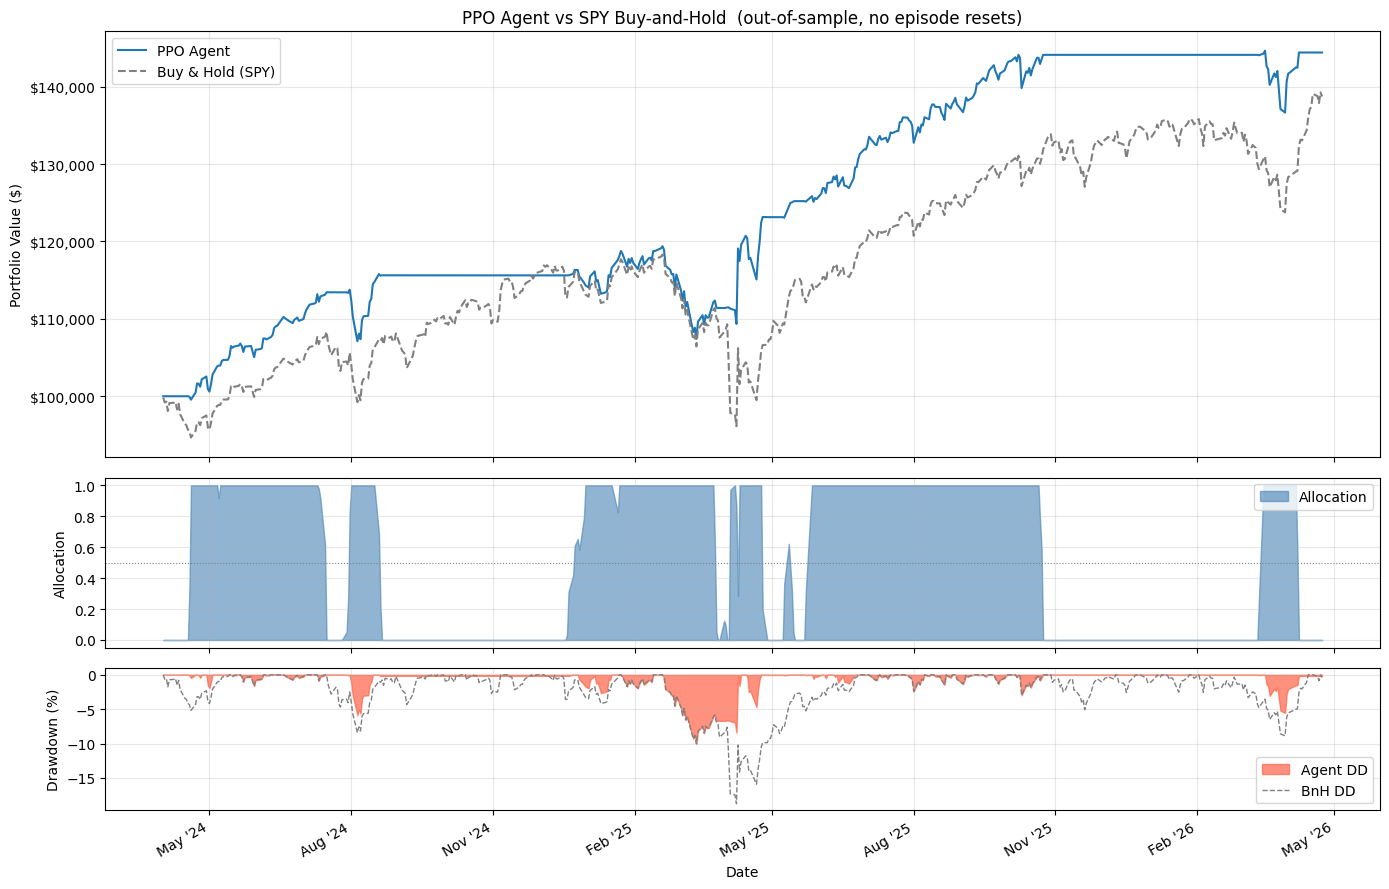

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def sharpe(returns):
    return float(np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252))

def max_dd(values):
    peak = np.maximum.accumulate(values)
    return float(((values - peak) / peak).min())

agent_vals = traj["portfolio_value"].to_numpy()
bnh_vals   = traj["bnh_value"].to_numpy()
agent_rets = np.diff(agent_vals) / agent_vals[:-1]
bnh_rets   = np.diff(bnh_vals)   / bnh_vals[:-1]

metrics = {
    "Total Return":  (agent_vals[-1]/agent_vals[0]-1, bnh_vals[-1]/bnh_vals[0]-1),
    "Sharpe Ratio":  (sharpe(agent_rets), sharpe(bnh_rets)),
    "Max Drawdown":  (max_dd(agent_vals), max_dd(bnh_vals)),
    "Avg Position":  (traj["position"].mean(), 1.0),
    "Final Value":   (agent_vals[-1], bnh_vals[-1]),
}

print(f"\n{'='*52}")
print(f"  SPY Out-of-Sample  {dates[1]}  →  {dates[-1]}")
print(f"{'='*52}")
print(f"{'Metric':<20} {'PPO Agent':>14} {'Buy & Hold':>14}")
print(f"{'─'*52}")
for k, (a, b) in metrics.items():
    if k == "Final Value":
        print(f"{k:<20} {a:>13,.2f}  {b:>13,.2f}")
    elif k in ("Total Return", "Max Drawdown"):
        print(f"{k:<20} {a:>+13.2%}  {b:>+13.2%}")
    elif k == "Avg Position":
        print(f"{k:<20} {a:>13.1%}  {b:>13.1%}")
    else:
        print(f"{k:<20} {a:>+13.3f}  {b:>+13.3f}")

print(f"\n  Return alpha  : {metrics['Total Return'][0]-metrics['Total Return'][1]:+.2%}")
print(f"  Sharpe alpha  : {metrics['Sharpe Ratio'][0]-metrics['Sharpe Ratio'][1]:+.3f}")
print(f"  DD improvement: {abs(metrics['Max Drawdown'][1])-abs(metrics['Max Drawdown'][0]):+.2%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_dates = pd.to_datetime(traj["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

# Panel 1: portfolio value
ax = axes[0]
ax.plot(plot_dates, agent_vals, label="PPO Agent", linewidth=1.5)
ax.plot(plot_dates, bnh_vals,   label="Buy & Hold (SPY)", linewidth=1.5, linestyle="--", color="gray")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title("PPO Agent vs SPY Buy-and-Hold  (out-of-sample, no episode resets)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(alpha=0.3)

# Panel 2: position allocation
ax = axes[1]
ax.fill_between(plot_dates, traj["position"].to_numpy(), alpha=0.6, label="Allocation", color="steelblue")
ax.set_ylabel("Allocation")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

# Panel 3: drawdown
def running_drawdown(vals):
    peak = np.maximum.accumulate(vals)
    return (vals - peak) / peak

ax = axes[2]
ax.fill_between(plot_dates, running_drawdown(agent_vals)*100, alpha=0.7, label="Agent DD", color="tomato")
ax.plot(plot_dates, running_drawdown(bnh_vals)*100, label="BnH DD", linewidth=1, linestyle="--", color="gray")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()